# Прикладные задачи анализа данных

## Домашнее задание 4

В этой работе мы будем решать задачу рекомендаций музыки. Для этого мы реализуем метод коллаборативной фильтрации и модель со скрытыми переменными, сравним их между собой и попытаемся сделать выводы. Во всех заданиях разрешается переписывать код по своему усмотрению, предложенные шаблоны несут лишь рекомендательный характер.

In [1]:
from sklearn.preprocessing import LabelEncoder

import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
from typing import Callable, List

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as scs

In [3]:
ratings = pd.read_csv('music_dataset.csv')
ratings.head()

,userId,trackId
0,0,14
1,0,95
2,0,219
3,0,220
4,0,404


In [4]:
tracks_info = pd.read_csv('tracks_info.csv')
tracks_info.head()

,id,name,artists
0,0,What There Is,['a-ha']
1,1,I'll Play The Blues For You,['Albert King']
2,2,Breaking Up Somebody's Home,['Albert King']
3,3,Imma Be,['Black Eyed Peas']
4,4,Boom Boom Pow,['Black Eyed Peas']


Для оценки качества рекомендаций мы будем использовать метрику $MAP@k$.

$$
MAP@k = \frac{1}{N} \sum_{u = 1}^N AP_u@k
$$
$$
AP_u@k = \frac{1}{\min(k, n_u)} \sum_{i=1}^k r_u(i) p_u@i
$$
$$p_u@k = \dfrac{1}{k}\sum_{j=1}^k r_u(j)$$


*   $N$ - количество пользователей.
*   $n_u$ - число релевантных треков пользователя $u$ на тестовом промежутке.
*   $r_u(i)$ - бинарная величина: относится ли трек на позиции $i$ к релевантным.

**Задание 1 (1 балл).** Реализуйте метрику $MAP@k$.

In [5]:
def apk(relevant: List[int], predicted: List[int], k: int = 20) -> float:
    if len(predicted) > k:
        predicted = predicted[:k]
    score = 0.0
    num_hits = 0.0
    for i in range(k):
        if i < len(predicted) and predicted[i] in relevant and predicted[i] not in predicted[:i]:
            num_hits += 1.0
            precision_at_i = num_hits / (i + 1.0)
            score += precision_at_i
    return score / min(len(relevant), k)

def mapk(relevant: List[List[int]], predicted: List[List[int]], k: int = 20) -> float:
    # your code here: (￣▽￣)/♫•*¨*•.¸¸♪
    if len(relevant) == 0:
        return 0.0
    total_ap = 0.0
    for rel, pred in zip(relevant, predicted):
        total_ap += apk(rel, pred, k)
    return total_ap / len(relevant)

In [6]:
relevant = [
    [1, 7, 6, 2, 8],
    [1, 5, 4, 8],
    [8, 2, 5]
]

pred = [
    [8, 1, 5, 0, 7, 2, 9, 4],
    [0, 1, 8, 5, 3, 4, 7, 9],
    [9, 2, 0, 6, 8, 5, 3, 7]
]

assert round(mapk(relevant, pred, k=5), 4) == 0.4331

Разделим данные на тренировочные и тестовые так, чтобы в теcтовый датасет попали 50 последних треков каждого пользователя.

In [7]:
def train_test_split(ratings):
    train_ratings, test_ratings = [], []
    num_test_samples = 50

    # getting train samples
    for userId, user_data in tqdm(ratings.groupby('userId')):
        train_ratings += [user_data[:-num_test_samples]]

    train_ratings = pd.concat(train_ratings).reset_index(drop=True)
    all_train_items = train_ratings['trackId'].unique()

    # getting train samples
    # we drop all tracks that are not presented it the training samples,
    # because we won't be able to learn representations for them
    for userId, user_data in tqdm(ratings.groupby('userId')):
        test_items = user_data[-num_test_samples:]
        test_items = test_items[np.isin(test_items['trackId'], all_train_items)]
        test_ratings += [test_items]

    test_ratings = pd.concat(test_ratings).reset_index(drop=True)

    return train_ratings, test_ratings

In [8]:
train_ratings, test_ratings = train_test_split(ratings)

  0%|          | 0/241 [00:00<?, ?it/s]

  0%|          | 0/241 [00:00<?, ?it/s]

Почистим табличку с информацией о треках и закодируем id треков так, чтобы они соответствовали их порядковому номеру.

In [9]:
redundant_rows = np.where(~np.isin(tracks_info['id'], train_ratings['trackId'].unique()))[0]
tracks_info.drop(redundant_rows, inplace=True)
tracks_info = tracks_info.reset_index(drop=True)

In [10]:
def ids_encoder(ratings):
    users = sorted(ratings['userId'].unique())
    items = sorted(ratings['trackId'].unique())

    # create users and items encoders
    uencoder = LabelEncoder()
    iencoder = LabelEncoder()

    # fit users and items ids to the corresponding encoder
    uencoder.fit(users)
    iencoder.fit(items)

    return uencoder, iencoder

In [11]:
uencoder, iencoder = ids_encoder(train_ratings)
train_ratings['trackId'] = iencoder.transform(train_ratings['trackId'].tolist())
test_ratings['trackId'] = iencoder.transform(test_ratings['trackId'].tolist())
tracks_info['id'] = iencoder.transform(tracks_info['id'].tolist())

In [12]:
train_ratings.head()

,userId,trackId
0,0,14
1,0,95
2,0,219
3,0,220
4,0,404


In [13]:
test_ratings.head()

,userId,trackId
0,0,57582
1,0,57802
2,0,57957
3,0,58174
4,0,59168


Соберем все релевантные треки для каждого пользователя в список.

In [14]:
test_relevant = []
test_users = []
for user_id, user_data in test_ratings.groupby('userId'):
    test_relevant += [user_data['trackId'].tolist()]
    test_users.append(user_id)

**Задание 2 (1 балл).** Реализуйте метод `get_test_recommendations` в классе `BaseModel`. Он принимает на вход параметр `k` и возвращает массив из `k` наиболее подходящих треков для каждого пользователя. Не забывайте удалять уже прослушанные треки из рекомендуемых.

In [15]:
class BaseModel:
    def __init__(self, ratings: pd.DataFrame):
        self.ratings = ratings
        self.n_users = len(np.unique(self.ratings['userId']))
        self.n_items = len(np.unique(self.ratings['trackId']))

        self.R = np.zeros((self.n_users, self.n_items))
        self.R[self.ratings['userId'], self.ratings['trackId']] = 1.

    def recommend(self, uid: int):
        """
        param uid: int - user's id
        return: [n_items] - vector of recommended items sorted by their scores in descending order
        """
        raise NotImplementedError

    def remove_train_items(self, preds: List[List[int]], k: int):
        """
        param preds: [n_users, n_items] - recommended items for each user
        param k: int
        return: np.array [n_users, k] - recommended items without training examples
        """
        new_preds = np.zeros((len(preds), k), dtype=int)
        for user_id, user_data in self.ratings.groupby('userId'):
            user_preds = preds[user_id]
            new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]

        return new_preds

    def get_test_recommendations(self, k: int):
        test_preds = []

        # your code here: (￣▽￣)/♫•*¨*•.¸¸♪
        for user_id in range(self.n_users):
            user_recommendations = self.recommend(user_id)
            test_preds.append(user_recommendations)

        test_preds = self.remove_train_items(test_preds, k)

        return test_preds[test_users]

## Часть 1. Коллаборативная фильтрация (User2User)

Идея: чтобы выбрать треки, которые понравятся пользователю, можно набрать несколько похожих на него пользователей (соседей) и посмотреть, какие треки они слушают. После этого остается агрегировать треки этих пользователей и выбрать самые популярные. Соответственно, задача состоит из двух частей: выбора функции похожести двух пользователей и способа агрегации.

В качестве функции похожести мы будем использовать две метрики:

1. Корреляция Пирсона $$s(u, v) = \frac{\sum_{i \in I_u \cap I_v} r_{ui}r_{vi}}{\sqrt{\sum_{i \in I_u} r_{ui} ^2}\sqrt{\sum_{i \in I_v} r_{vi}^2}} $$

2. Мера Жаккара

$$ s(u, v) = \frac{|I_u \cap I_v|}{|I_u \cup I_v|} $$


Корреляция Пирсона немного видоизменена, чтобы подходить под нашу задачу.


Во всех формулах
* $I_u$ - множество треков, прослушанных пользователем $u$.
* $r_{ui}$ - прослушал ли пользователь $u$ трек $i$ (0 или 1).

Множество соседей определим как $$N(u) = \{ v \in U \setminus \{u\} \mid s(u, v) > \alpha\},$$ где $\alpha \, - $ гиперпараметр.



Для агрегации мы будем пользоваться следующей формулой.
$$
\hat{r}_{ui} = \frac{\sum_{v \in N(u)} s(u, v) r_{vi}}{\sum_{v \in N(u)} |s(u, v)|}
$$

**Задание 3.1 (1 балл).** Реализуйте функцию подсчета корреляции Пирсона.

**Задание 3.2 (1 балл).** Реализуйте функцию подсчета меры Жаккара.

Функции принимают матрицу оценок и вектор оценок пользователя $u$ и возвращают вектор со значениями похожести пользователя $u$ на всех пользователей. Старайтесь писать оптимизированный код, за неэффективную реализацию оценка может быть снижена.

In [16]:
def pearson(ratings: np.array, user_vector: np.array) -> np.array:
    # your code here: (￣▽￣)/♫•*¨*•.¸¸♪
    user_rated_mask = user_vector > 0
    user_mean = np.sum(user_vector) / np.sum(user_rated_mask)
    user_centered = (user_vector - user_mean) * user_rated_mask

    ratings_mask = ratings > 0
    users_means = np.sum(ratings, axis=1) / np.sum(ratings_mask, axis=1)
    ratings_centered = (ratings - users_means[:, np.newaxis]) * ratings_mask

    numerator = np.dot(ratings_centered, user_centered)
    user_norm = np.sqrt(np.sum(user_centered ** 2))
    ratings_norms = np.sqrt(np.sum(ratings_centered ** 2, axis=1))

    return numerator / (user_norm * ratings_norms + 1e-10)

def jaccard(ratings: np.array, user_vector: np.array) -> np.array:
    # your code here: (￣▽￣)/♫•*¨*•.¸¸♪
    intersection = np.sum((ratings > 0) & (user_vector[np.newaxis, :] > 0), axis=1)
    union = np.sum((ratings > 0) | (user_vector[np.newaxis, :] > 0), axis=1)
    return intersection / (union + 1e-10)

**Задание 4 (1 балл).** Реализуйте методы `similarity` и `recommend` класса `User2User`. `recommend` возвращает индексы треков, отсортированные в порядке убывания предсказанных оценок.


In [17]:
class User2User(BaseModel):
    def __init__(self, ratings, similarity_func):
        super().__init__(ratings)

        assert similarity_func in [pearson, jaccard]

        self.similarity_func = similarity_func
        self.alpha = 0.02

    def similarity(self, user_vector: np.array):
        """
        user_vector: [n_items]
        """
        # your code here: (￣▽￣)/♫•*¨*•.¸¸♪
        return self.similarity_func(self.R, user_vector)

    def recommend(self, uid: int):
        # your code here: (￣▽￣)/♫•*¨*•.¸¸♪
        user_vector = self.R[uid]
        similarities = self.similarity(user_vector)
        neighbor_indices = np.argwhere(similarities > self.alpha).flatten()
        item_scores = np.zeros(self.n_items)
        for idx in neighbor_indices:
          item_scores += similarities[idx] * self.R[idx]
        normalization = np.abs(similarities[neighbor_indices]).sum() + 1e-10
        item_scores /= normalization
        not_rated = np.where(self.R[uid] == 0)[0]
        return not_rated[np.argsort(-item_scores[not_rated])]

**Задание 5 (1 балл).** Постройте графики зависимости значений $MAP@k$ от разных $k$ для обоих функций похожести, сравните их между собой, а также с предсказаниями случайного алгоритма и сделайте выводы.

In [18]:
class RandomModel(BaseModel):
    def recommend(self, uid: int):
        unseen_items = np.where(self.R[uid] == 0)[0]
        return np.random.permutation(unseen_items)

In [ ]:
ks = [5, 10, 25, 50, 75, 100]
results = {'k': ks, 'Pearson': [], 'Jaccard': [], 'Random': []}

pearson_model = User2User(train_ratings, pearson)
jaccard_model = User2User(train_ratings, jaccard)
random_model = RandomModel(train_ratings)

for k in ks:
    pearson_preds = pearson_model.get_test_recommendations(k)
    jaccard_preds = jaccard_model.get_test_recommendations(k)
    random_preds = random_model.get_test_recommendations(k)

    pearson_mapk = mapk(test_relevant, pearson_preds, k)
    jaccard_mapk = mapk(test_relevant, jaccard_preds, k)
    random_mapk = mapk(test_relevant, random_preds, k)

    results['Pearson'].append(pearson_mapk)
    results['Jaccard'].append(jaccard_mapk)
    results['Random'].append(random_mapk)

<ipython-input-55-1060231821>:26: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]


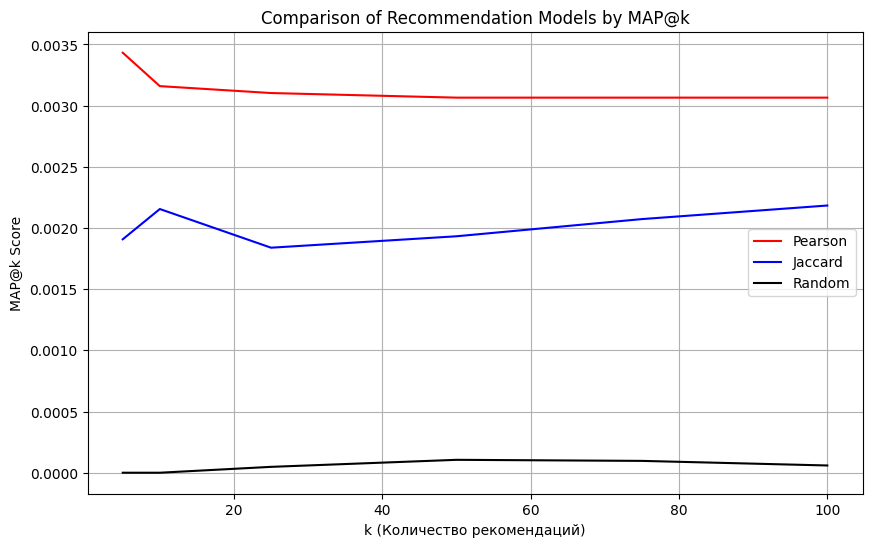

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(results['k'], results['Pearson'], label='Pearson', color = 'red')
plt.plot(results['k'], results['Jaccard'], label='Jaccard', color = 'blue')
plt.plot(results['k'], results['Random'], label='Random', color = 'black')
plt.xlabel('k (Количество рекомендаций)')
plt.ylabel('MAP@k Score')
plt.title('Comparison of Recommendation Models by MAP@k')
plt.legend()
plt.grid()
plt.show()

Метрика MAP@k оценивает релевантность списка рекомендуемых элементов, и более высокие значения указывают на лучшее качество рекомендаций

* Функция Пирсона демонстрирует наилучшие результаты, так как её значения MAP@k значительно выше, чем у других методов, для всех значений
k

* Случайный алгоритм занимает худшее положение, то есть является не эффективным

* Увеличение количества предсказаний улучшает результат для функции Жакара, для Пирсона результат не меняется

**Задание 6 (1.5 балла).** Как вы могли заметить, матрица оценок получается очень разреженной, но мы работаем с ней как с обычной, это не дело. Перепишите код так, чтобы все методы могли работать с разреженными матрицами и сравните скорость работы такого подхода с оригинальным.

In [ ]:
from scipy.sparse import csr_matrix, lil_matrix

In [ ]:
class BaseModelSparse:
    def __init__(self, ratings: pd.DataFrame):
        self.ratings = ratings
        self.n_users = len(np.unique(self.ratings['userId']))
        self.n_items = len(np.unique(self.ratings['trackId']))

        self.R = lil_matrix((self.n_users, self.n_items))
        for _, row in ratings.iterrows():
            self.R[row['userId'], row['trackId']] = 1

    def recommend(self, uid: int):
        raise NotImplementedError

    def remove_train_items(self, preds: List[List[int]], k: int):
        new_preds = np.zeros((len(preds), k), dtype=int)

        for user_id in range(len(preds)):
            user_preds = preds[user_id]
            rated_items = self.R.rows[user_id]
            filtered_preds = [item for item in user_preds if item not in rated_items][:k]
            if len(filtered_preds) < k:
                filtered_preds = filtered_preds + [-1] * (k - len(filtered_preds))
            new_preds[user_id] = filtered_preds

        return new_preds

    def get_test_recommendations(self, k: int):
        test_preds = []
        for user_id in range(self.n_users):
            user_recommendations = self.recommend(user_id)
            test_preds.append(user_recommendations)
        return self.remove_train_items(test_preds, k)

In [ ]:
def pearson_sparse(ratings: csr_matrix, user_vector: np.array) -> np.array:
    user_vector_sparse = csr_matrix(user_vector)
    user_rated = user_vector.nonzero()[0]
    user_mean = user_vector[user_rated].mean() if len(user_rated) > 0 else 0
    user_centered = user_vector.copy()
    user_centered[user_rated] -= user_mean

    ratings_csr = ratings.tocsr()
    user_counts = np.diff(ratings_csr.indptr)
    user_sums = np.array(ratings_csr.sum(axis=1)).flatten()
    users_means = np.zeros(ratings_csr.shape[0])
    mask = user_counts > 0
    users_means[mask] = user_sums[mask] / user_counts[mask]

    ratings_centered = ratings_csr.copy().astype(np.float64)
    for i in range(ratings_csr.shape[0]):
        if user_counts[i] > 0:
            start, end = ratings_csr.indptr[i], ratings_csr.indptr[i+1]
            ratings_centered.data[start:end] -= users_means[i]

    numerator = ratings_centered.dot(user_centered)
    user_norm = np.sqrt((user_centered**2).sum())
    ratings_norms = np.sqrt(np.array(ratings_centered.power(2).sum(axis=1))).flatten()
    similarity = numerator / (user_norm * ratings_norms + 1e-10)
    similarity[np.isnan(similarity)] = 0

    return similarity

def jaccard_sparse(ratings: lil_matrix, user_vector: np.array) -> np.array:
    similarities = np.zeros(ratings.shape[0])
    user_items = set(np.where(user_vector > 0)[0])

    for i in range(ratings.shape[0]):
        row_items = set(ratings.rows[i])
        intersection = len(user_items & row_items)
        union = len(user_items | row_items)
        similarities[i] = intersection / (union + 1e-10)

    return similarities

In [ ]:
class User2UserSparse(BaseModelSparse):
    def __init__(self, ratings, similarity_func, alpha=0.02):
        super().__init__(ratings)
        self.similarity_func = similarity_func
        self.alpha = alpha

    def recommend(self, uid: int):
        user_vector = self.R[uid].toarray().flatten()
        similarities = self.similarity_func(self.R, user_vector)

        similar_users = np.where(similarities > self.alpha)[0]

        similar_users = similar_users[similar_users != uid]

        if len(similar_users) == 0:
            return np.array([], dtype=int)

        scores = self.R[similar_users].sum(axis=0).A1 * similarities[similar_users]
        scores = scores / (similarities[similar_users].sum() + 1e-10)

        unrated_mask = np.array(self.R[uid] == 0).flatten()
        unrated_items = np.where(unrated_mask)[0]

        sorted_items = unrated_items[np.argsort(-scores[unrated_items])]
        return sorted_items

In [ ]:
class RandomModelSparse(BaseModelSparse):
    def recommend(self, uid: int):
        unrated_mask = np.array(self.R[uid] == 0).flatten()
        unseen_items = np.where(unrated_mask)[0]
        return np.random.permutation(unseen_items)

In [ ]:
ks = [5, 10, 25, 50, 75, 100]
results = {'k': ks, 'Pearson': [], 'Jaccard': [], 'Random': []}

pearson_model = User2UserSparse(train_ratings, pearson_sparse)
jaccard_model = User2UserSparse(train_ratings, jaccard_sparse)
random_model = RandomModelSparse(train_ratings)

for k in ks:
    pearson_preds = pearson_model.get_test_recommendations(k)
    jaccard_preds = jaccard_model.get_test_recommendations(k)
    random_preds = random_model.get_test_recommendations(k)

    pearson_mapk = mapk(test_relevant, pearson_preds, k)
    jaccard_mapk = mapk(test_relevant, jaccard_preds, k)
    random_mapk = mapk(test_relevant, random_preds, k)

    results['Pearson'].append(pearson_mapk)
    results['Jaccard'].append(jaccard_mapk)
    results['Random'].append(random_mapk)

ValueError: operands could not be broadcast together with shapes (67313,) (4,) 

попытки были но не вышло

Мы можем посмотреть глазами, насколько хорошо модель рекомендует треки. Для этого сравним уже прослушанные треки с рекомендованными и релевантными для случайного пользователя. Хорошо ли у вас получилось?

In [ ]:
user_id = np.random.randint(0, pearson_model.n_users)

In [ ]:
listened_tracks = train_ratings[train_ratings.userId == user_id].trackId[:15]

print('Already listened tracks:')

tracks_info.loc[listened_tracks][['name', 'artists']]

Already listened tracks:


,name,artists
258,What A Wonderful World,['Louis Armstrong']
805,Zombie,['The Cranberries']
933,Sonne,['Rammstein']
1073,Smells Like Teen Spirit,['Nirvana']
1101,Ohne Dich,['Rammstein']
1102,Amerika,['Rammstein']
1131,The Unforgiven,['Metallica']
1137,Nothing Else Matters,['Metallica']
1672,Song 2,['Blur']
2481,Gangsta's Paradise,"['Coolio', 'L.V.']"


In [ ]:
preds = pearson_model.get_test_recommendations(15)

print('Predicted tracks:')

tracks_info.loc[preds[user_id]][['name', 'artists']]

<ipython-input-55-1060231821>:26: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]


Predicted tracks:


,name,artists
67303,Ещё выше,['Градусы']
67302,KILLASTORE II,"['PHOROMANE', 'Phonk Killer']"
67301,De Dragul Tău,['INNA']
67300,Aurora,['Geoxor']
67299,Blusk,['Geoxor']
67298,Не упоминай Бруно,"['Юлия Чуракова', 'Михаил Хрусталёв', 'Ксения ..."
67297,На самом деле,['Таис Урумидис']
67296,Букет крапивы,['Noize MC']
67295,Выход в город,['Noize MC']
67294,KALMAR,['Nikitata']


В прослушанных только западная музыка, преимущественно рок и чуть чуть классика (Луи Армстронг), в предсказаниях получилась российская поп музыка, сомнительно конечно

In [ ]:
test_tracks = test_ratings[test_ratings.userId == user_id].trackId[:15]

print('Test-time tracks:')

tracks_info.loc[test_tracks][['name', 'artists']]

Test-time tracks:


,name,artists
64046,Всем счастья,['Главная Роль']
64118,Wellerman,['The Wellermen']
64182,SNEAKY,['WYR GEMI']
64325,Кхуям,['Хитобои']
64377,А река течёт,"['Любэ', 'Николай Расторгуев']"
64536,Tu Turu Tutu,"['Beowülf', 'D-Groov']"
64596,Нету интереса,['10AGE']
64805,Somebody To Love,['Basstrologe']
65084,Valhalla Calling,['Peyton Parrish']
65142,Я никогда не стану феминисткой,['Nodahsa']


ну видимо тип меломан раз после тренировочной выборки тут такая подборка, возможно из-за того что неполный список выводит, то кажется, что перекос такой сильный, целиком бы посмотреть

### Часть 2. Модель со скрытыми переменными

В этой части мы пощупаем метод рекомендаций со скрытыми переменными.
Идея: будем предсказывать оценки по формуле
$$
\hat{r}_{ui} = \langle p_u, q_u \rangle,
$$
$p_u \in \mathbb{R}^d$ и $q_i \in \mathbb{R}^d$ - латентные векторы пользователя $u$ и объекта $i$ соответственно.

Оптимизировать мы будем MSE между истинной оценкой пользователя и предсказанной с регуляризацией
$$
L = \sum_{(u, i) \in R} (\hat{r}_{ui} - r_{ui})^2 + \lambda \left(\sum_{u \in U} \|p_u\|^2 + \sum_{i \in I} \|q_i\|^2\right)
$$

**Задание 7 (1.5 балла).** На лекции рассматривались два подхода к оптимизации параметров. Можно это делать обычным стохастческим градинтным спуском, а можно по очереди обновлять матрицы $P, Q$, и тогда получится метод Alternating Least Squares (ALS). Вспомните формулы обновления и поясните их:

### **SGD (Стохастический градиентный спуск)**

Оптимизируем функцию потерь, обновляя параметры $p_u$ (вектор пользователя) и $q_i$ (вектор предмета) через градиентный спуск.

#### **Функция потерь (для пары $(u, i)$):**
$$
L_{ui} = (\hat{r}_{ui} - r_{ui})^2 + \lambda (\|p_u\|^2 + \|q_i\|^2)
$$

#### **Градиенты:**
$$
\frac{\partial L_{ui}}{\partial p_u} = 2(\hat{r}_{ui} - r_{ui}) q_i + 2\lambda p_u
$$

$$
\frac{\partial L_{ui}}{\partial q_i} = 2(\hat{r}_{ui} - r_{ui}) p_u + 2\lambda q_i
$$

#### **Обновление параметров:**
$$
p_u \leftarrow p_u - \eta \cdot \left[2(\hat{r}_{ui} - r_{ui}) q_i + 2\lambda p_u\right]
$$

$$
q_i \leftarrow q_i - \eta \cdot \left[2(\hat{r}_{ui} - r_{ui}) p_u + 2\lambda q_i\right]
$$

**Где:**  
- $\eta$ — скорость обучения (learning rate)  
- $\lambda$ — коэффициент регуляризации  

### **ALS (Alternating Least Squares)**

Попеременно фиксируем один набор параметров и оптимизируем другой.

#### **Шаг 1: Фиксируем $Q$, обновляем $p_u$**
$$
p_u = \left(\sum_{i \in I_u} q_i q_i^T + \lambda I\right)^{-1} \left(\sum_{i \in I_u} r_{ui} q_i\right)
$$

#### **Шаг 2: Фиксируем $P$, обновляем $q_i$**
$$
q_i = \left(\sum_{u \in U_i} p_u p_u^T + \lambda I\right)^{-1} \left(\sum_{u \in U_i} r_{ui} p_u\right)
$$

**Где:**  
- $I_u$ — множество предметов, оценённых пользователем $u$  
- $U_i$ — множество пользователей, оценивших предмет $i$  
- $I$ — единичная матрица размера $d \times d$  


**Задание 8 (2 балла).** А теперь реализуйте методы оптимизации параметров для обоих алгоритмов.

In [19]:
class HiddenVars(BaseModel):
    def __init__(self, ratings, dim=128, mode='sgd', lamb=0.01):
        super().__init__(ratings)
        self.dim = dim

        assert mode in ['sgd', 'als']
        self.mode = mode

        self.P = np.random.normal(size=(self.n_users, dim))
        self.Q = np.random.normal(size=(self.n_items, dim))

        self.lr = 0.0003
        self.lamb = lamb
        self.R = scs.csr_matrix(self.R)

    def fit(self, num_iters=5):
        total_loss = 0
        for it in tqdm(range(num_iters)):
            if self.mode == 'sgd':
                idx = np.random.randint(self.ratings.shape[0])
                row = self.ratings.iloc[idx].to_numpy()
                user_vec, item_vec = self.P[row[0]], self.Q[row[1]]

                decay = 1 - self.lr * self.lamb
                gradient = self.lr * (user_vec @ item_vec.T - 1)

                self.P[row[0]] = user_vec * decay - item_vec * gradient
                self.Q[row[1]] = item_vec * decay - user_vec * gradient

            elif self.mode == 'als':
                Q_T = self.Q.T
                Q_mat = self.Q
                eye = np.eye(self.dim)

                reg_users = Q_T @ Q_mat + self.lamb * eye
                R_csr = scs.csr_matrix(self.R)

                self.P = R_csr @ Q_mat @ np.linalg.inv(reg_users)

                P_mat = self.P
                reg_items = P_mat.T @ P_mat + self.lamb * eye

                self.Q = R_csr.T @ P_mat @ np.linalg.inv(reg_items)

        predicted = self.P @ self.Q.T
        diff = self.R - predicted

        mse = sc.linalg.norm(diff) ** 2
        reg_term = self.lamb * (np.sum(self.P ** 2) + np.sum(self.Q ** 2))

        return mse + reg_term

    def recommend(self, uid):
        pred_rating = self.P[uid] @ self.Q.T
        return np.argsort(pred_rating)[::-1]

**Задание 9 (1 балл).** Для обоих алгоритмов подберите оптимальные значения размерности скрытого пространства $d$ и размера предсказания $k$. Как изменяется качество предсказаний с числом итераций обучения? Постройте соответствующие графики, сравните со случайным подхом и User2User, сделайте выводы. Какой алгоритм вам кажется более подходящим для данной задачи и почему?

P.S. Хотя бы один из методов обучения должен приводить к лучшим результатам в сравнении с User2User подходом.

P.P.S. Методу LFM свойственно переобучаться, поэтому при подборе параметров полезно смотреть на значения ошибки и оптимизируемой метрики на тренировочном датасете. Вы также можете менять начальную инициализацию и прочие параметры, за исключением архитектуры, на ваш вкус.

In [20]:
from sklearn.metrics import mean_squared_error
import scipy as sc

  0%|          | 0/1 [00:00<?, ?it/s]

<ipython-input-15-2581572122>:26: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  new_preds[user_id] = user_preds[~np.in1d(user_preds, user_data['trackId'])][:k]


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

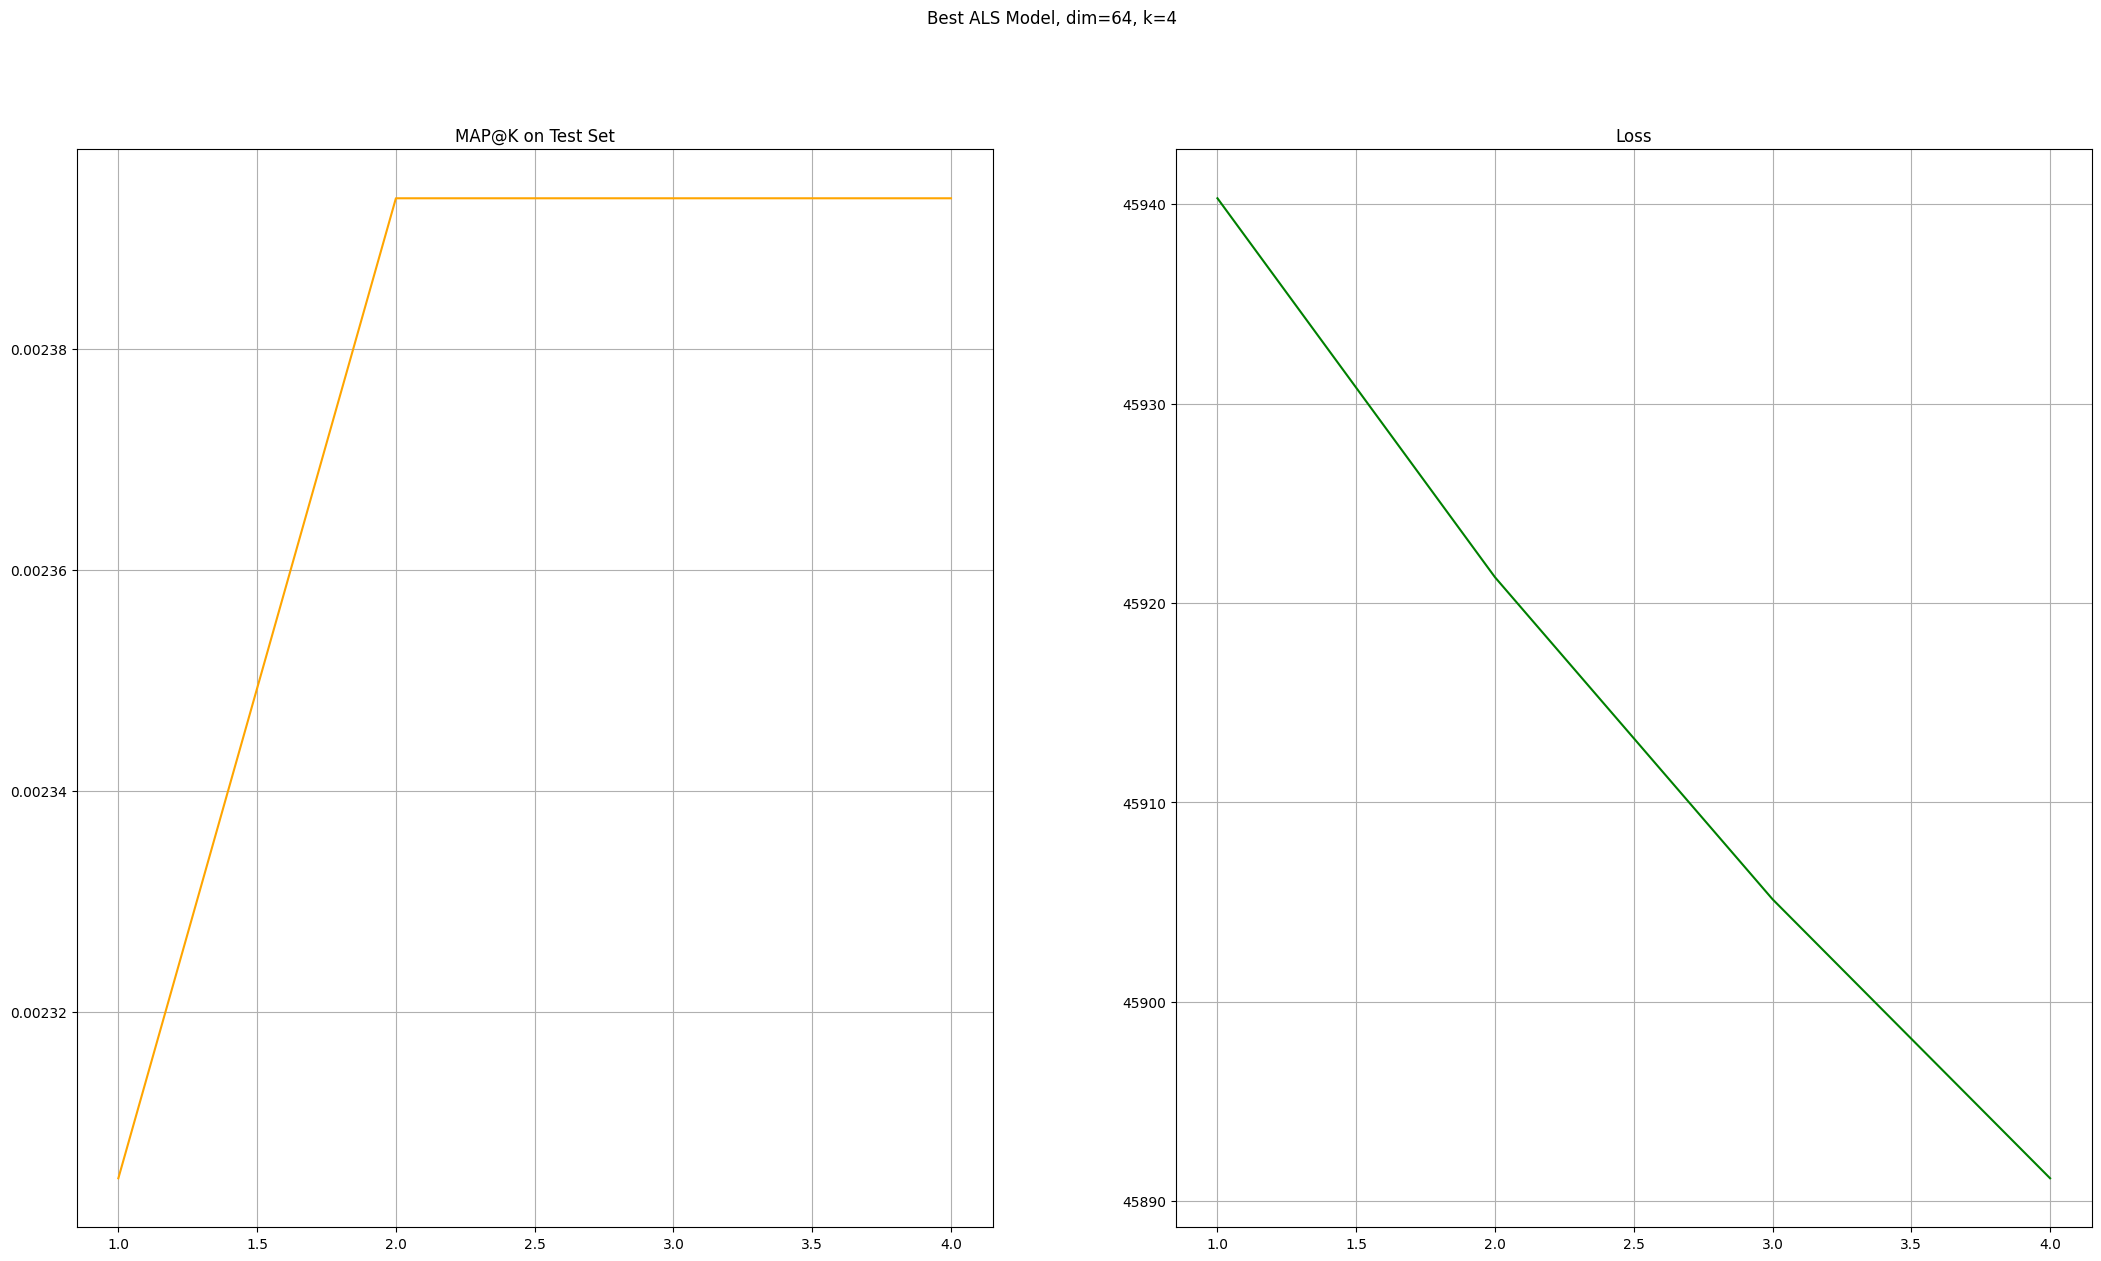

Best model parameters: dim=64, k=4, best MAP@K=0.0023936170212765957


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

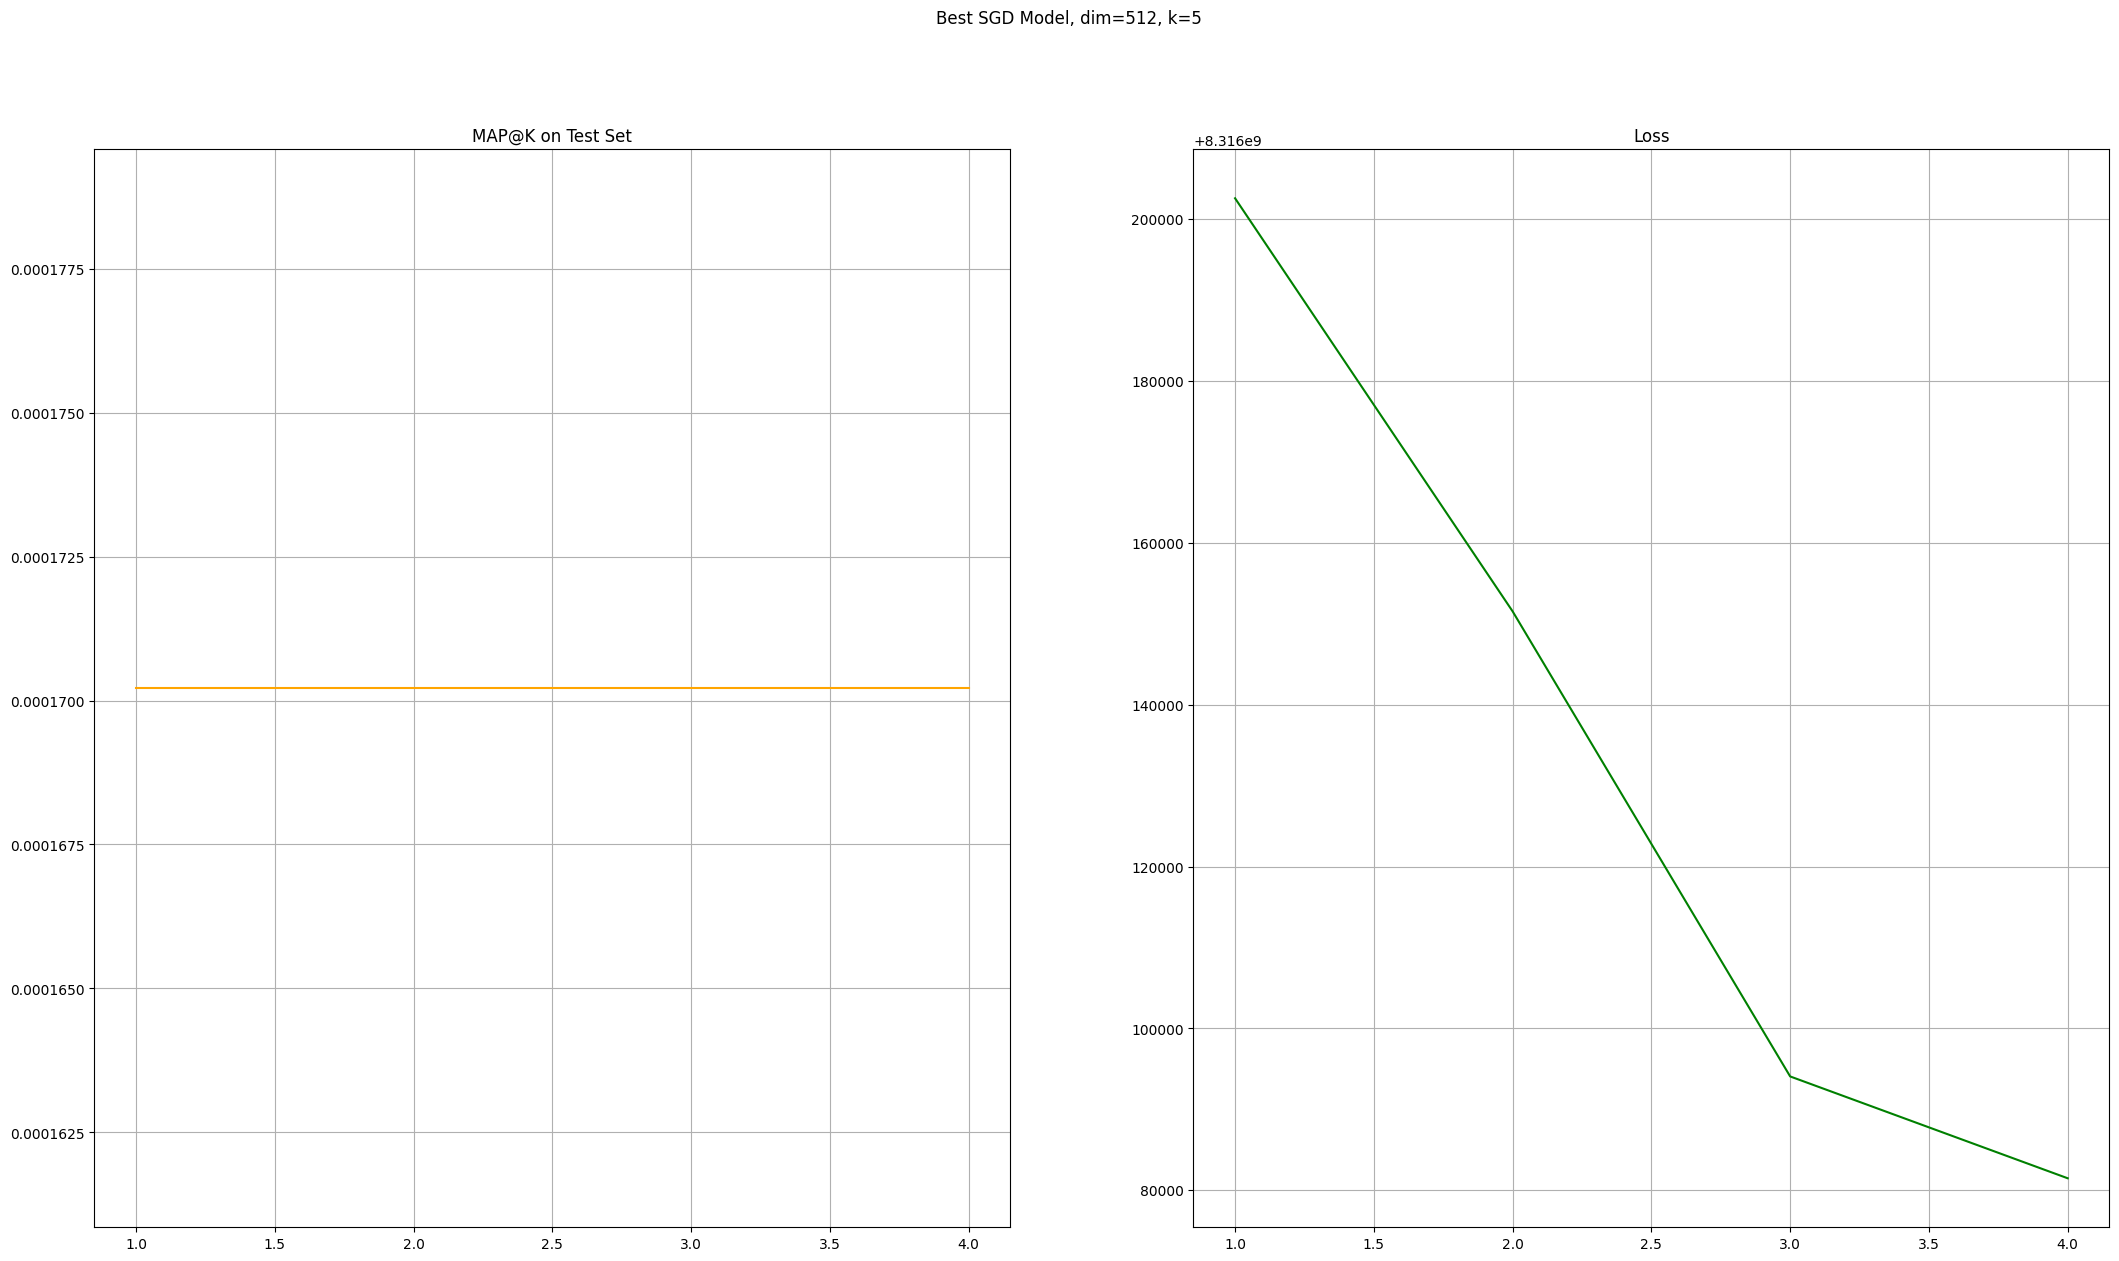

Best model parameters: dim=512, k=5, best MAP@K=0.00017021276595744682


In [21]:
def search_best_model(train_ratings, test_relevant, mode_name):
    optimal_mapk = -1
    optimal_dim = None
    optimal_k = None
    loss_history = []
    mapk_history = []

    dims = [32, 64, 128, 256, 512]
    for latent_dim in dims:
        recommender = HiddenVars(train_ratings, dim=latent_dim, mode=mode_name, lamb=0.01)
        for top_k in range(1, 16):
            current_mapk = []
            current_loss = []
            for epoch in range(4):
                current_loss.append(recommender.fit(1))
                current_mapk.append(mapk(test_relevant, recommender.get_test_recommendations(top_k), top_k))
            if current_mapk[-1] > optimal_mapk:
                optimal_mapk = current_mapk[-1]
                optimal_dim = latent_dim
                optimal_k = top_k
                loss_history = current_loss.copy()
                mapk_history = current_mapk.copy()

    fig, axs = plt.subplots(1, 2, figsize=(26, 14))
    axs[0].grid()
    axs[1].grid()
    fig.suptitle(f"Best {mode_name.upper()} Model, dim={optimal_dim}, k={optimal_k}")
    axs[1].set_title("Loss")
    axs[0].set_title("MAP@K on Test Set")
    axs[0].plot(range(1, len(mapk_history) + 1), mapk_history, color='orange')
    axs[1].plot(range(1, len(loss_history) + 1), loss_history, color='green')
    plt.show()

    print(f"Best model parameters: dim={optimal_dim}, k={optimal_k}, best MAP@K={optimal_mapk}")

# Поиск для ALS
model_als = search_best_model(train_ratings, test_relevant, mode_name='als')

# Поиск для SGD
model_sgd = search_best_model(train_ratings, test_relevant, mode_name='sgd')


час работало(((

* ALS: Best model parameters: dim=64, k=4, best MAP@K=0.0023936170212765957 - лучше случайного алгоритма, чуть лучше Жаккара, но хуже Пирсона

* SGD: Best model parameters: dim=512, k=5, best MAP@K=0.00017021276595744682 - он справился совсем плохо

Если у вас получилось достаточно хорошее качество, то при оптимизации параметров марицы $Q$ похожим трекам стали соответствовать похожие векторы. Поэтому мы можем для любого трека найти наиболее близкие к нему в латентном пространстве и проверить степерь обученности модели вручную.

In [25]:
example_trackId = tracks_info[tracks_info.name == 'Выхода нет'].iloc[0].id

preds = model_als.Q @ model_als.Q[example_trackId]
preds = preds / np.sqrt((model_als.Q**2).sum(axis=1) + 1e-8)

track_idxs = preds.argsort()[::-1][:20]

AttributeError: 'NoneType' object has no attribute 'Q'

In [26]:
similar_tracks = tracks_info.loc[track_idxs][['name', 'artists']]
similar_tracks['similarity'] = preds[track_idxs] / np.linalg.norm(model_als.Q[example_trackId])
similar_tracks

NameError: name 'track_idxs' is not defined